In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ")

All libraries loaded 


In [3]:
def build_train_data(file_number):
    """
    Loads a raw training .txt file and computes the RUL label for each row.
    For training data: EOL = last cycle of each engine (run-to-failure data).
    RUL = EOL - current Cycle
    """
    col_names = [
        'ID', 'Cycle',
        'OpSet1', 'OpSet2', 'OpSet3',
        'SensorMeasure1',  'SensorMeasure2',  'SensorMeasure3',
        'SensorMeasure4',  'SensorMeasure5',  'SensorMeasure6',
        'SensorMeasure7',  'SensorMeasure8',  'SensorMeasure9',
        'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12',
        'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15',
        'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18',
        'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21'
    ]
    
    raw = pd.read_csv(
        f'train_FD00{file_number}.txt',
        sep=' ', header=None
    ).drop([26, 27], axis=1)
    
    raw.columns = col_names
    
    # EOL = maximum cycle reached by each engine (it ran to failure)
    eol_map = raw.groupby('ID')['Cycle'].max()
    raw['EOL'] = raw['ID'].map(eol_map)
    
    # RUL = how many cycles remain from this point
    raw['RUL'] = raw['EOL'] - raw['Cycle']
    
    # Drop helper columns — ID not needed as a feature
    raw = raw.drop(columns=['ID', 'EOL'])
    
    raw['dataset'] = file_number   # track which sub-dataset it came from
    
    return raw


# Build and combine all 4 training datasets
train_dfs = [build_train_data(i) for i in range(1, 5)]
df_all = pd.concat(train_dfs, ignore_index=True)

print(f"Total training rows: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")
df_all.head()

Total training rows: 160359
Columns: ['Cycle', 'OpSet1', 'OpSet2', 'OpSet3', 'SensorMeasure1', 'SensorMeasure2', 'SensorMeasure3', 'SensorMeasure4', 'SensorMeasure5', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8', 'SensorMeasure9', 'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12', 'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15', 'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21', 'RUL', 'dataset']


,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure6,...,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL,dataset
0,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,1
1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,1
2,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,1
3,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,1
4,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,1


In [4]:
def build_test_data(file_number):
    """
    Loads a raw test .txt file and computes true RUL using the RUL_FD00X.txt file.
    For test data: EOL = last cycle seen in test + remaining cycles from RUL file.
    """
    col_names = [
        'ID', 'Cycle',
        'OpSet1', 'OpSet2', 'OpSet3',
        'SensorMeasure1',  'SensorMeasure2',  'SensorMeasure3',
        'SensorMeasure4',  'SensorMeasure5',  'SensorMeasure6',
        'SensorMeasure7',  'SensorMeasure8',  'SensorMeasure9',
        'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12',
        'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15',
        'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18',
        'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21'
    ]
    
    raw = pd.read_csv(
        f'test_FD00{file_number}.txt',
        sep=' ', header=None
    ).drop([26, 27], axis=1)
    raw.columns = col_names
    
    # Last cycle seen per engine in test data
    last_cycle = raw.groupby('ID')['Cycle'].max().values.reshape(-1, 1)
    
    # Remaining cycles after test snapshot (from RUL file)
    rul_file = pd.read_csv(
        f'RUL_FD00{file_number}.txt',
        sep=' ', header=None
    ).drop([1], axis=1).values
    
    eol = last_cycle + rul_file  # true end of life
    
    # Map EOL back to each row
    raw['EOL'] = raw['ID'].map({i+1: eol[i][0] for i in range(len(eol))})
    raw['RUL'] = raw['EOL'] - raw['Cycle']
    raw = raw.drop(columns=['ID', 'EOL'])
    raw['dataset'] = file_number
    
    return raw


# Build and combine all 4 test datasets
test_dfs = [build_test_data(i) for i in range(1, 5)]
df_test_all = pd.concat(test_dfs, ignore_index=True)

print(f"Total test rows: {len(df_test_all)}")
df_test_all.head()

Total test rows: 104897


,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure6,...,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL,dataset
0,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142,1
1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141,1
2,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140,1
3,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139,1
4,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138,1


In [5]:
print("=== Training Data Overview ===")
print(f"Shape: {df_all.shape}")
print(f"\nRUL range: {df_all['RUL'].min()} → {df_all['RUL'].max()}")
print(f"Engines per dataset (count of RUL==0 rows):")
for i in range(1, 5):
    count = (df_all[df_all['dataset'] == i]['RUL'] == 0).sum()
    print(f"  FD00{i}: {count} engines")

=== Training Data Overview ===
Shape: (160359, 27)

RUL range: 0 → 542
Engines per dataset (count of RUL==0 rows):
  FD001: 100 engines
  FD002: 260 engines
  FD003: 100 engines
  FD004: 249 engines


In [6]:
# Baseline Regression (No EDA, No Feature Selection)

In [7]:
# Use FD001 only for baseline (clean, single operating condition)
df_baseline = df_all[df_all['dataset'] == 1].drop(columns=['dataset'])

X_base = df_baseline.iloc[:, :-1]   # all sensor/cycle columns
y_base = df_baseline['RUL']

# shuffle=False preserves time-series order (important for engines!)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, shuffle=False
)

print(f"Train size: {X_train_b.shape}, Test size: {X_test_b.shape}")

Train size: (16504, 25), Test size: (4127, 25)


In [8]:
rf_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_b, y_train_b)

# Evaluate
y_pred_train_b = rf_baseline.predict(X_train_b)
y_pred_test_b  = rf_baseline.predict(X_test_b)

train_rmse = np.sqrt(metrics.mean_squared_error(y_train_b, y_pred_train_b))
test_rmse  = np.sqrt(metrics.mean_squared_error(y_test_b,  y_pred_test_b))
test_mae   = metrics.mean_absolute_error(y_test_b, y_pred_test_b)
test_r2    = metrics.r2_score(y_test_b, y_pred_test_b)

print("=" * 40)
print("   BASELINE MODEL RESULTS (FD001)")
print("=" * 40)
print(f"  Train RMSE : {train_rmse:.2f} cycles")
print(f"  Test  RMSE : {test_rmse:.2f}  cycles")
print(f"  Test  MAE  : {test_mae:.2f}  cycles")
print(f"  Test  R²   : {test_r2:.4f}")
print("=" * 40)

   BASELINE MODEL RESULTS (FD001)
  Train RMSE : 12.08 cycles
  Test  RMSE : 49.29  cycles
  Test  MAE  : 35.69  cycles
  Test  R²   : 0.6073


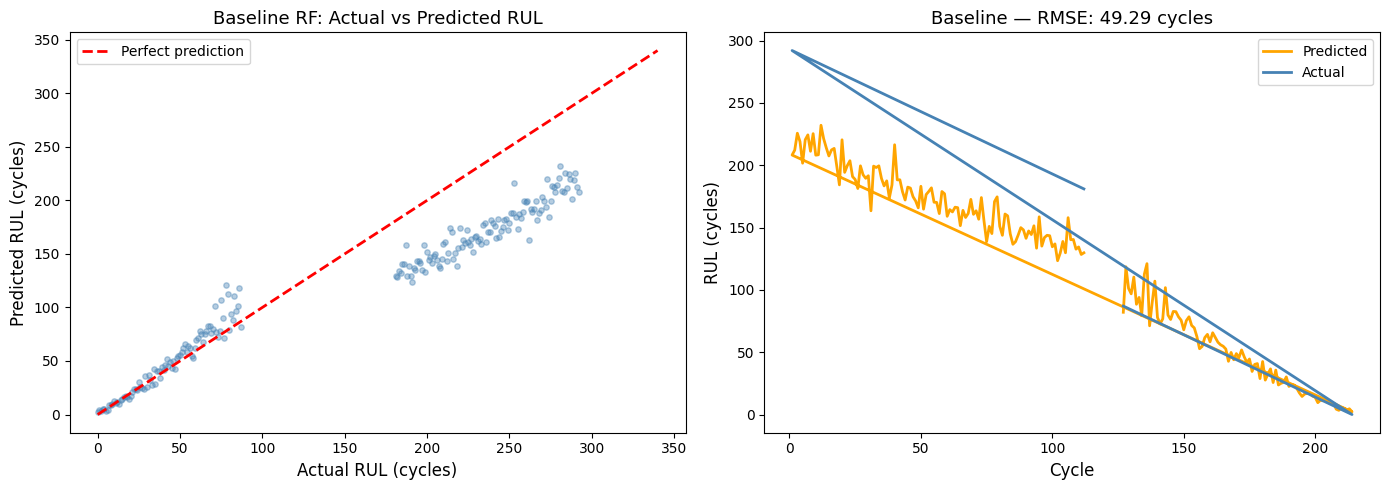


⚠️  High RMSE (49.3) → Model needs EDA + Feature Selection


In [9]:
# Show one engine's prediction vs actual
engine_mask = X_test_b.index[:200]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Prediction vs Actual (scatter)
axes[0].scatter(y_test_b[:200], y_pred_test_b[:200], alpha=0.4, color='steelblue', s=15)
axes[0].plot([0, y_test_b.max()], [0, y_test_b.max()], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12)
axes[0].set_title('Baseline RF: Actual vs Predicted RUL', fontsize=13)
axes[0].legend()

# Right: Over time for first engine in test set
cycle_vals = X_test_b['Cycle'].values[:200]
axes[1].plot(cycle_vals, y_pred_test_b[:200], label='Predicted', color='orange', lw=2)
axes[1].plot(cycle_vals, y_test_b.values[:200], label='Actual', color='steelblue', lw=2)
axes[1].set_xlabel('Cycle', fontsize=12)
axes[1].set_ylabel('RUL (cycles)', fontsize=12)
axes[1].set_title(f'Baseline — RMSE: {test_rmse:.2f} cycles', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150)
plt.show()

print(f"\n⚠️  High RMSE ({test_rmse:.1f}) → Model needs EDA + Feature Selection")

In [10]:
#  PART 2 — Exploratory Data Analysis (EDA)

In [11]:
# Use FD001 for EDA (single operating condition, cleaner patterns)
df_eda = df_all[df_all['dataset'] == 1].drop(columns=['dataset'])

print("=== Basic Statistics ===")
print(f"Shape: {df_eda.shape}")
print(f"\nNull values: {df_eda.isnull().sum().sum()}")
df_eda.describe().T

=== Basic Statistics ===
Shape: (20631, 26)

Null values: 0


,count,mean,std,min,25%,50%,75%,max
Cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
OpSet1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
OpSet2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
OpSet3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
SensorMeasure1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
SensorMeasure2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
SensorMeasure3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
SensorMeasure4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
SensorMeasure5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
SensorMeasure6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100


In [12]:
unique_counts = df_eda.nunique().sort_values()
print("=== Unique value counts per feature ===")
print(unique_counts)

# Highlight constant features — they carry zero information
constant_features = unique_counts[unique_counts <= 1].index.tolist()
print(f"\n🚫 Constant features (zero variance): {constant_features}")

=== Unique value counts per feature ===
OpSet3                1
SensorMeasure1        1
SensorMeasure10       1
SensorMeasure5        1
SensorMeasure18       1
SensorMeasure19       1
SensorMeasure16       1
SensorMeasure6        2
SensorMeasure17      13
OpSet2               13
SensorMeasure8       53
SensorMeasure13      56
SensorMeasure20     120
OpSet1              158
SensorMeasure11     159
SensorMeasure2      310
RUL                 362
Cycle               362
SensorMeasure12     427
SensorMeasure7      513
SensorMeasure15    1918
SensorMeasure3     3012
SensorMeasure4     4051
SensorMeasure21    4745
SensorMeasure14    6078
SensorMeasure9     6403
dtype: int64

🚫 Constant features (zero variance): ['OpSet3', 'SensorMeasure1', 'SensorMeasure10', 'SensorMeasure5', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure16']


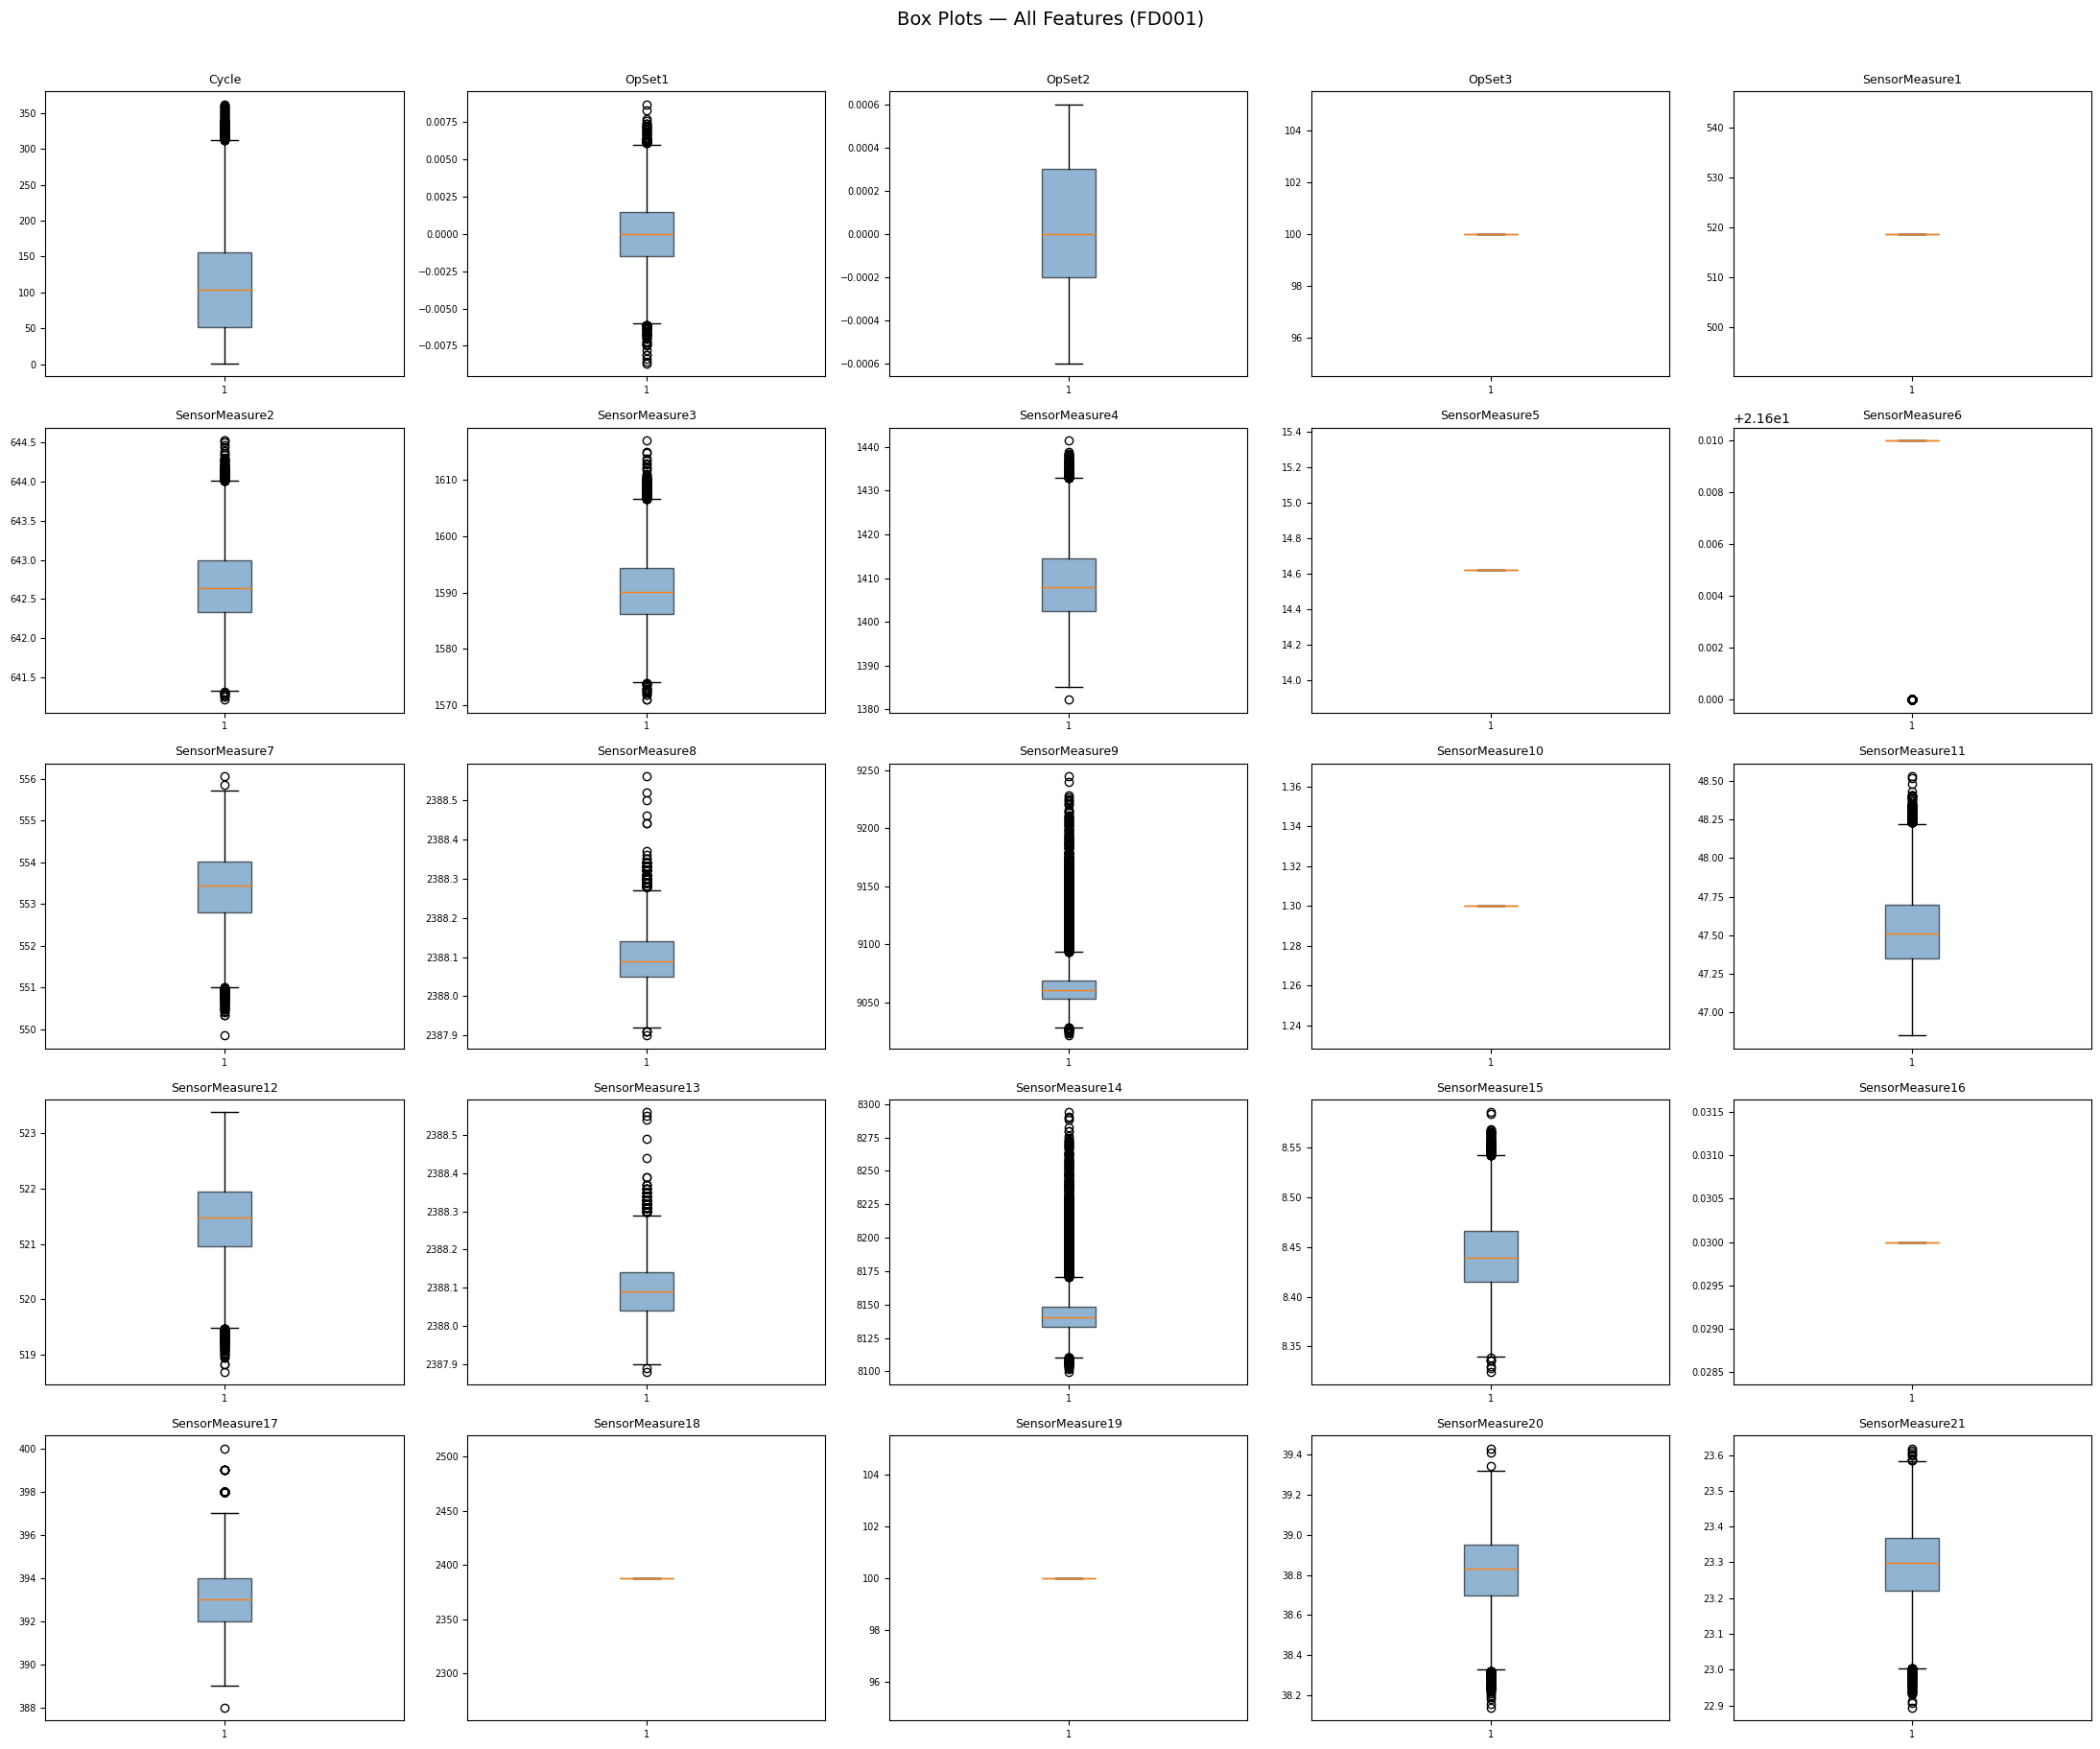

In [13]:
feature_cols = [c for c in df_eda.columns if c != 'RUL']

fig, axes = plt.subplots(5, 5, figsize=(22, 18))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_eda[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — All Features (FD001)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

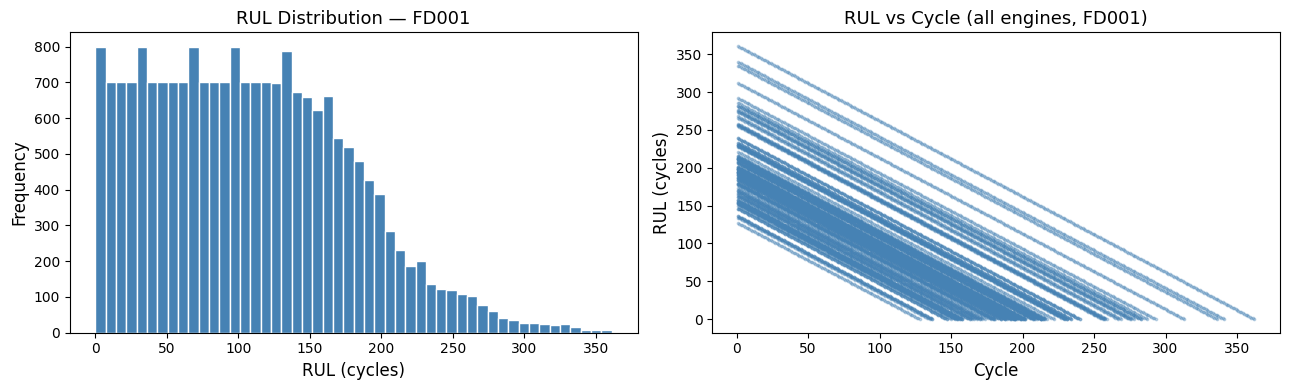

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_eda['RUL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('RUL Distribution — FD001', fontsize=13)

# RUL over engine life for a few sample engines
for eng_id in [1, 5, 10, 20]:
    eng = df_eda.reset_index(drop=True)
    # Rebuild engine-specific view from baseline df
    eng_data = df_all[(df_all['dataset'] == 1)].copy()
    # We need to reload with ID for this plot
    pass

# Simple: plot RUL vs Cycle for all of FD001
axes[1].scatter(df_eda['Cycle'], df_eda['RUL'], s=3, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Cycle', fontsize=12)
axes[1].set_ylabel('RUL (cycles)', fontsize=12)
axes[1].set_title('RUL vs Cycle (all engines, FD001)', fontsize=13)

plt.tight_layout()
plt.savefig('rul_distribution.png', dpi=150)
plt.show()

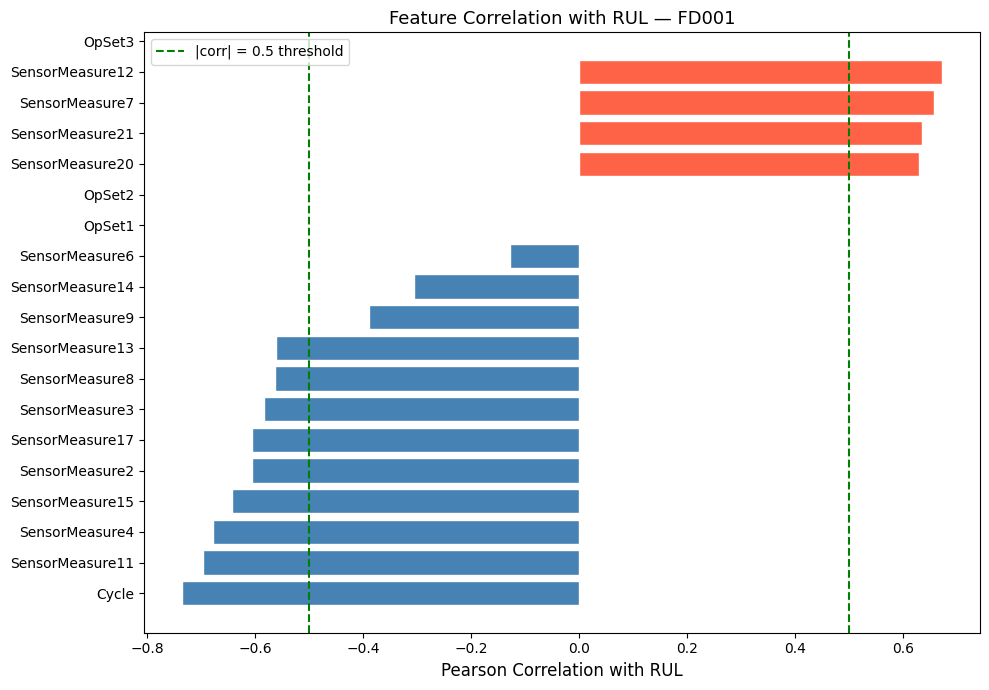


✅ Strong features (|corr| > 0.5): ['Cycle', 'SensorMeasure11', 'SensorMeasure4', 'SensorMeasure15', 'SensorMeasure2', 'SensorMeasure17', 'SensorMeasure3', 'SensorMeasure8', 'SensorMeasure13', 'SensorMeasure20', 'SensorMeasure21', 'SensorMeasure7', 'SensorMeasure12']

❌ Weak features to drop:          ['SensorMeasure9', 'SensorMeasure14', 'SensorMeasure6', 'OpSet1', 'OpSet2']


In [15]:
corr_with_rul = df_eda.corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(10, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_with_rul]
bars = plt.barh(corr_with_rul.index, corr_with_rul.values, color=colors, edgecolor='white')
plt.axvline(x=0.5, color='green', linestyle='--', lw=1.5, label='|corr| = 0.5 threshold')
plt.axvline(x=-0.5, color='green', linestyle='--', lw=1.5)
plt.xlabel('Pearson Correlation with RUL', fontsize=12)
plt.title('Feature Correlation with RUL — FD001', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('correlation_with_rul.png', dpi=150)
plt.show()

# Features above threshold
strong_features = corr_with_rul[abs(corr_with_rul) > 0.5].index.tolist()
weak_features   = corr_with_rul[abs(corr_with_rul) <= 0.5].index.tolist()
print(f"\n✅ Strong features (|corr| > 0.5): {strong_features}")
print(f"\n❌ Weak features to drop:          {weak_features}")

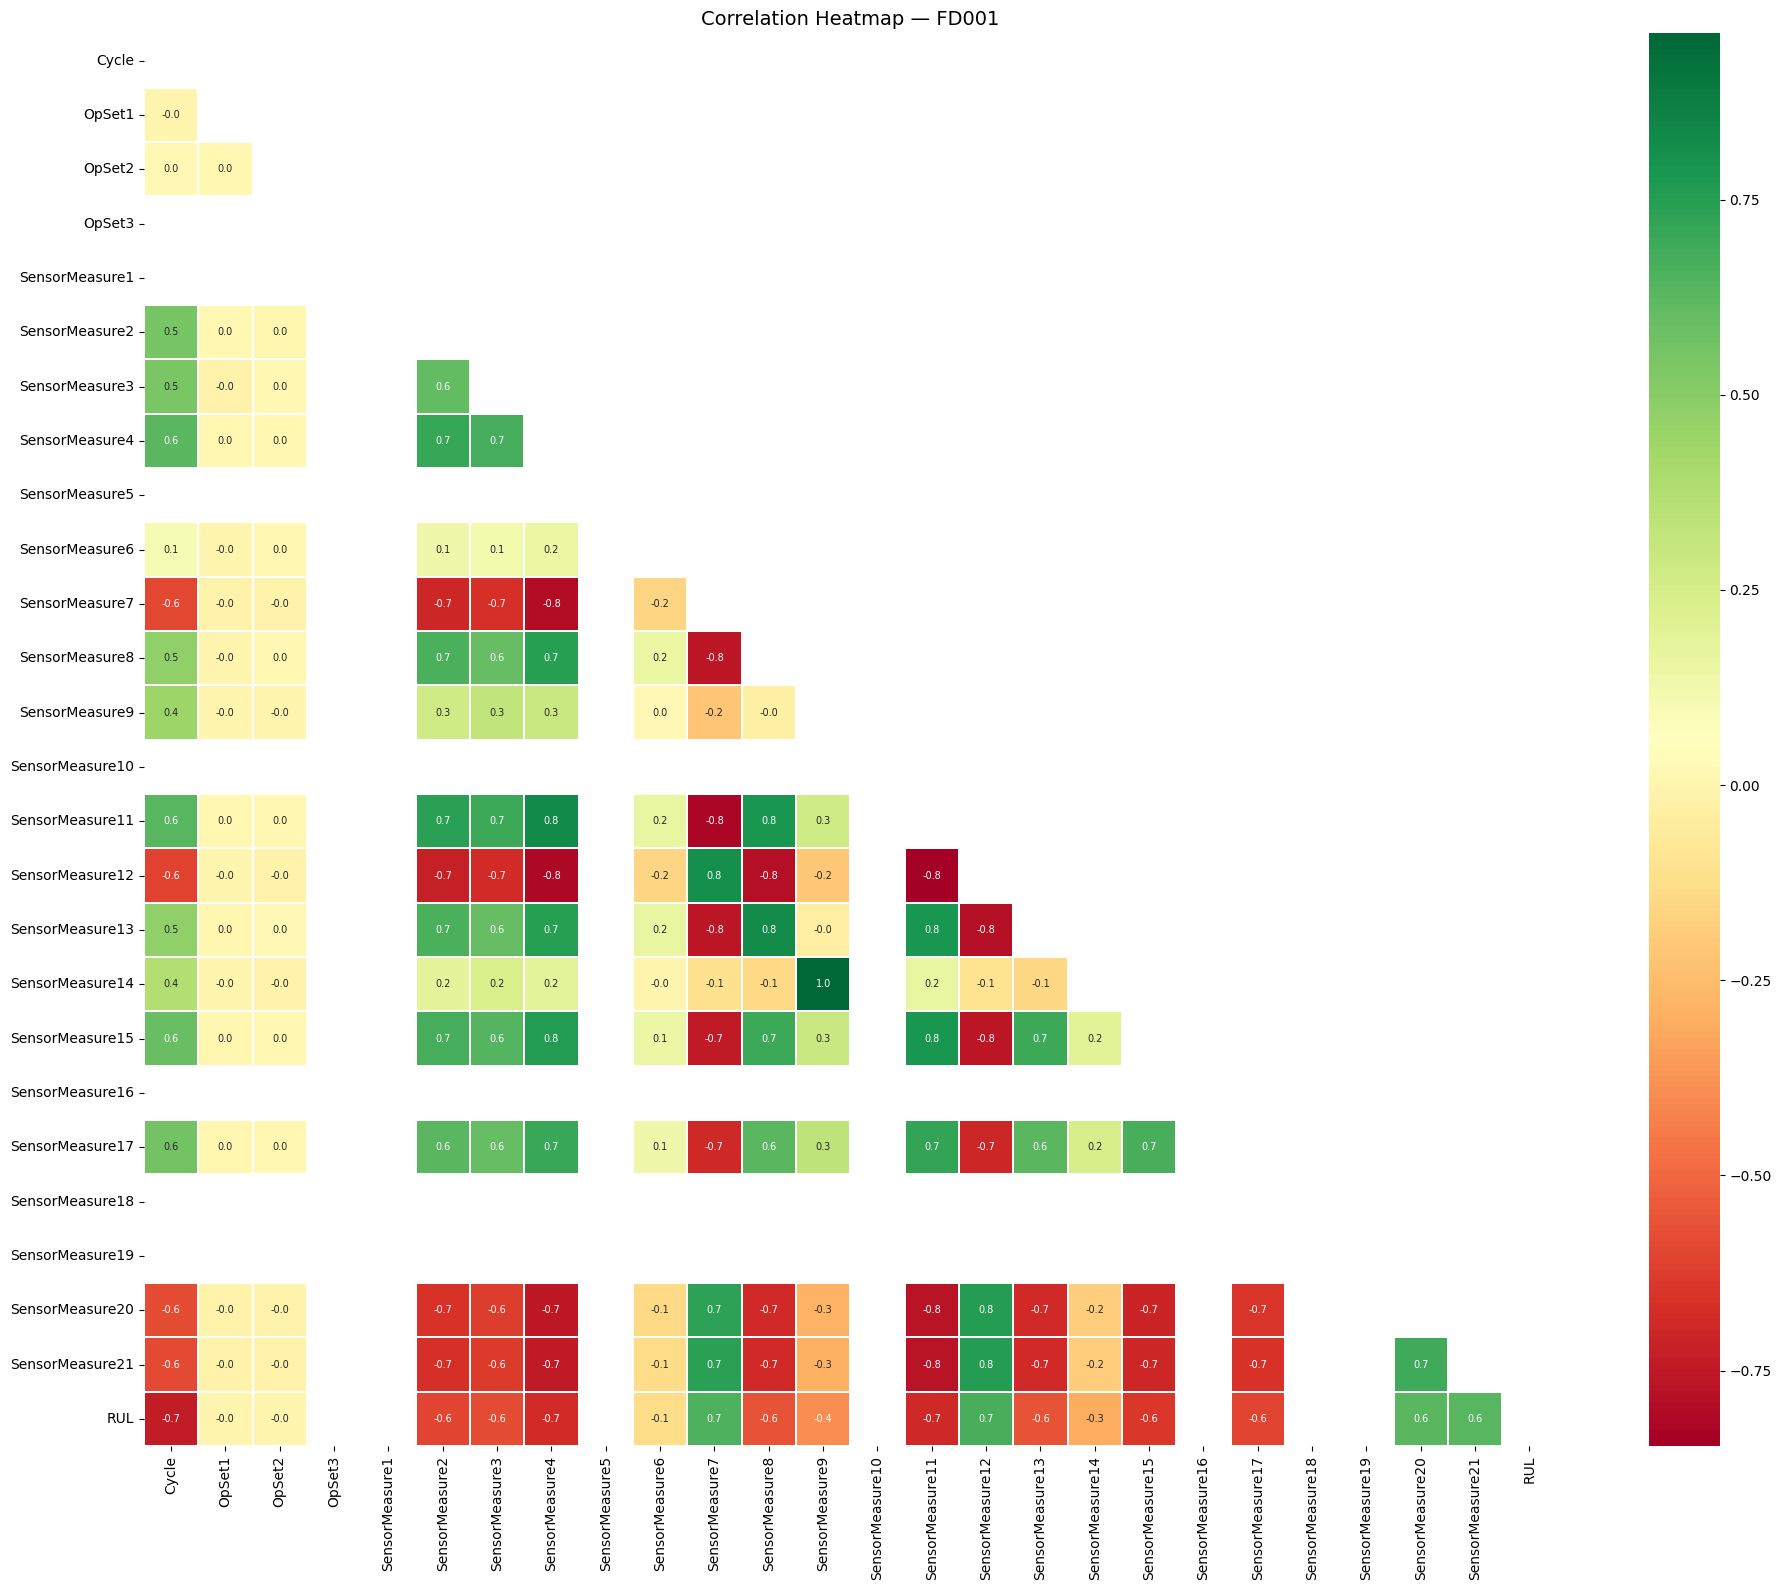

In [16]:
plt.figure(figsize=(20, 16))
corr_matrix = df_eda.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    linewidths=0.3,
    square=True
)
plt.title('Correlation Heatmap — FD001', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Drop features with weak correlation to RUL
drop_cols = weak_features.copy()
print(f"Dropping {len(drop_cols)} low-correlation features:\n{drop_cols}")

df_selected = df_eda.drop(columns=drop_cols)
print(f"\nRemaining shape: {df_selected.shape}")
df_selected.head()

Dropping 5 low-correlation features:
['SensorMeasure9', 'SensorMeasure14', 'SensorMeasure6', 'OpSet1', 'OpSet2']

Remaining shape: (20631, 21)


,Cycle,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure7,SensorMeasure8,SensorMeasure10,...,SensorMeasure12,SensorMeasure13,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL
0,1,100.0,518.67,641.82,1589.70,1400.60,14.62,554.36,2388.06,1.3,...,521.66,2388.02,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,2,100.0,518.67,642.15,1591.82,1403.14,14.62,553.75,2388.04,1.3,...,522.28,2388.07,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,3,100.0,518.67,642.35,1587.99,1404.20,14.62,554.26,2388.08,1.3,...,522.42,2388.03,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,4,100.0,518.67,642.35,1582.79,1401.87,14.62,554.45,2388.11,1.3,...,522.86,2388.08,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,5,100.0,518.67,642.37,1582.85,1406.22,14.62,554.00,2388.06,1.3,...,522.19,2388.04,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


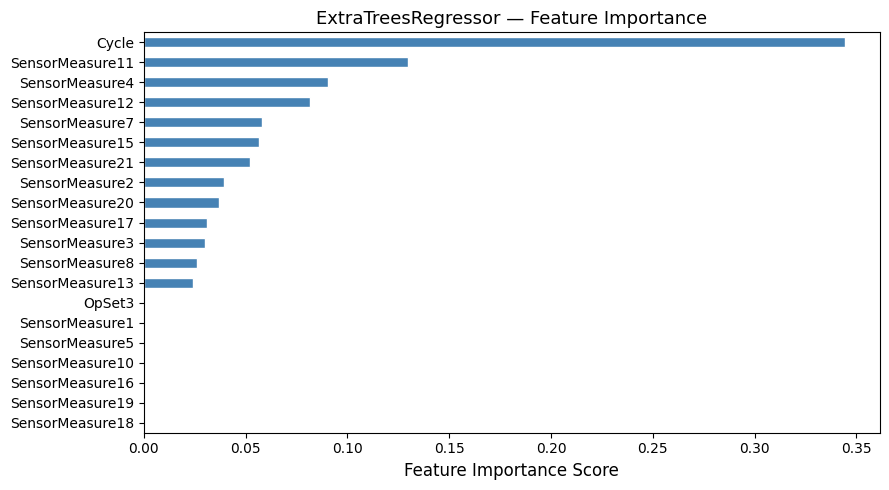


Ranked features:
Cycle              0.344361
SensorMeasure11    0.129979
SensorMeasure4     0.090355
SensorMeasure12    0.081484
SensorMeasure7     0.057944
SensorMeasure15    0.056433
SensorMeasure21    0.052044
SensorMeasure2     0.039132
SensorMeasure20    0.036670
SensorMeasure17    0.031189
SensorMeasure3     0.030140
SensorMeasure8     0.026330
SensorMeasure13    0.023938
OpSet3             0.000000
SensorMeasure1     0.000000
SensorMeasure5     0.000000
SensorMeasure10    0.000000
SensorMeasure16    0.000000
SensorMeasure19    0.000000
SensorMeasure18    0.000000
dtype: float64


In [18]:
X_ft = df_selected.iloc[:, :-1]
y_ft = df_selected['RUL']

et_model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_model.fit(X_ft, y_ft)

feat_importances = pd.Series(
    et_model.feature_importances_,
    index=X_ft.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('ExtraTreesRegressor — Feature Importance', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nRanked features:")
print(feat_importances)

In [19]:
# Reorder df columns by importance rank
ordered_features = feat_importances.index.tolist()
feat_imp_df = df_selected[ordered_features]

n_features_list, test_rmse_list, train_rmse_list = [], [], []

print(f"{'Features':>10} | {'Test RMSE':>10} | {'Train RMSE':>10}")
print("-" * 38)

for n in range(1, len(ordered_features) + 1):
    X_n = feat_imp_df.iloc[:, :n]
    y_n = df_selected['RUL']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_n, y_n, test_size=0.2, shuffle=False
    )
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    tr_rmse = np.sqrt(metrics.mean_squared_error(y_tr, rf.predict(X_tr)))
    te_rmse = np.sqrt(metrics.mean_squared_error(y_te, rf.predict(X_te)))

    n_features_list.append(n)
    test_rmse_list.append(te_rmse)
    train_rmse_list.append(tr_rmse)

    print(f"{n:>10} | {te_rmse:>10.2f} | {tr_rmse:>10.2f}")

# Find optimal count
best_n = n_features_list[np.argmin(test_rmse_list)]
print(f"\n🏆 Optimal number of features: {best_n} "
      f"(Test RMSE: {min(test_rmse_list):.2f})")

  Features |  Test RMSE | Train RMSE
--------------------------------------
         1 |      60.35 |      39.33
         2 |      55.84 |      23.49
         3 |      52.85 |      13.61
         4 |      52.08 |      13.18
         5 |      51.78 |      13.01
         6 |      51.31 |      12.86
         7 |      51.33 |      12.77
         8 |      50.96 |      12.69
         9 |      50.90 |      12.69
        10 |      50.87 |      12.65
        11 |      50.83 |      12.63
        12 |      50.90 |      12.60
        13 |      50.90 |      12.58
        14 |      50.85 |      12.57
        15 |      50.86 |      12.58
        16 |      50.90 |      12.58
        17 |      50.94 |      12.59
        18 |      50.91 |      12.58
        19 |      50.88 |      12.58
        20 |      50.86 |      12.58

🏆 Optimal number of features: 11 (Test RMSE: 50.83)


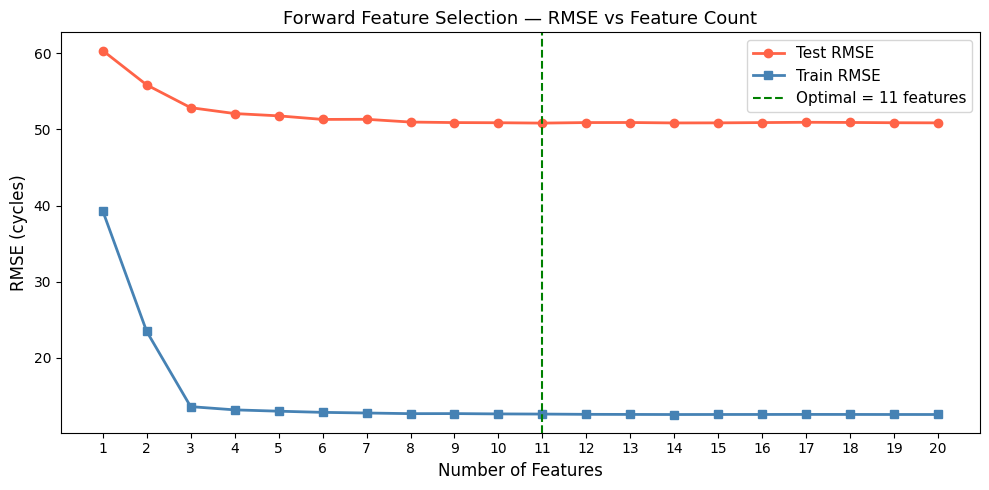

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(n_features_list, test_rmse_list,  'o-', color='tomato',    lw=2, label='Test RMSE')
plt.plot(n_features_list, train_rmse_list, 's-', color='steelblue', lw=2, label='Train RMSE')
plt.axvline(x=best_n, color='green', linestyle='--', lw=1.5, label=f'Optimal = {best_n} features')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('RMSE (cycles)', fontsize=12)
plt.title('Forward Feature Selection — RMSE vs Feature Count', fontsize=13)
plt.legend(fontsize=11)
plt.xticks(n_features_list)
plt.tight_layout()
plt.savefig('forward_selection.png', dpi=150)
plt.show()

In [21]:
# Keep only the top N features
best_features = ordered_features[:best_n]
print(f"✅ Final selected features ({best_n}):\n{best_features}")

df_final = df_selected[best_features + ['RUL']]
print(f"\nFinal dataset shape: {df_final.shape}")
df_final.head()

✅ Final selected features (11):
['Cycle', 'SensorMeasure11', 'SensorMeasure4', 'SensorMeasure12', 'SensorMeasure7', 'SensorMeasure15', 'SensorMeasure21', 'SensorMeasure2', 'SensorMeasure20', 'SensorMeasure17', 'SensorMeasure3']

Final dataset shape: (20631, 12)


,Cycle,SensorMeasure11,SensorMeasure4,SensorMeasure12,SensorMeasure7,SensorMeasure15,SensorMeasure21,SensorMeasure2,SensorMeasure20,SensorMeasure17,SensorMeasure3,RUL
0,1,47.47,1400.60,521.66,554.36,8.4195,23.4190,641.82,39.06,392,1589.70,191
1,2,47.49,1403.14,522.28,553.75,8.4318,23.4236,642.15,39.00,392,1591.82,190
2,3,47.27,1404.20,522.42,554.26,8.4178,23.3442,642.35,38.95,390,1587.99,189
3,4,47.13,1401.87,522.86,554.45,8.3682,23.3739,642.35,38.88,392,1582.79,188
4,5,47.28,1406.22,522.19,554.00,8.4294,23.4044,642.37,38.90,393,1582.85,187


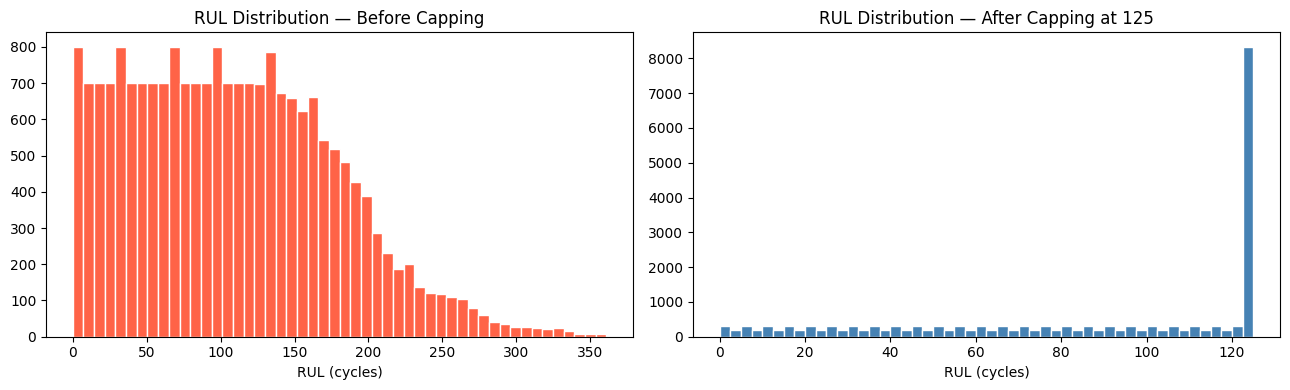

Before cap → max RUL: 361,  mean: 107.8
After  cap → max RUL: 125, mean: 86.8


In [22]:
# ============================================
# RUL CAPPING — Standard in CMAPSS literature
# Cap RUL at 125: engine is "healthy" above 
# this threshold, degradation starts below it
# ============================================

RUL_CAP = 125

df_final_capped = df_final.copy()
df_final_capped['RUL'] = df_final_capped['RUL'].clip(upper=RUL_CAP)

# Visualize the effect of capping
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_final['RUL'],        bins=50, color='tomato',    edgecolor='white')
axes[0].set_title('RUL Distribution — Before Capping', fontsize=12)
axes[0].set_xlabel('RUL (cycles)')

axes[1].hist(df_final_capped['RUL'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'RUL Distribution — After Capping at {RUL_CAP}', fontsize=12)
axes[1].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.savefig('rul_capping.png', dpi=150)
plt.show()

print(f"Before cap → max RUL: {df_final['RUL'].max()},  mean: {df_final['RUL'].mean():.1f}")
print(f"After  cap → max RUL: {df_final_capped['RUL'].max()}, mean: {df_final_capped['RUL'].mean():.1f}")

In [23]:
from sklearn.preprocessing import MinMaxScaler

# Use CAPPED version
X_final = df_final_capped.iloc[:, :-1]
y_final = df_final_capped['RUL']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, shuffle=False, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"RUL range after cap → Train: 0–{y_train.max()}, Test: 0–{y_test.max()}")

Train: (16504, 11), Test: (4127, 11)
RUL range after cap → Train: 0–125, Test: 0–125


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [10, 20, 30, None],
    'max_samples':  [0.6, 0.7, 0.8],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf, param_grid,
    n_iter=15, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_scaled, y_train)

print(f"\nBest Params : {rf_search.best_params_}")
print(f"Best CV RMSE: {-rf_search.best_score_:.2f} cycles")

# Evaluate best RF
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

rf_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))
rf_mae  = metrics.mean_absolute_error(y_test, y_pred_rf)
rf_r2   = metrics.r2_score(y_test, y_pred_rf)

print(f"\n{'='*40}")
print(f"  TUNED RANDOM FOREST RESULTS")
print(f"{'='*40}")
print(f"  RMSE : {rf_rmse:.2f} cycles")
print(f"  MAE  : {rf_mae:.2f}  cycles")
print(f"  R²   : {rf_r2:.4f}")
print(f"{'='*40}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Params : {'n_estimators': 300, 'min_samples_split': 5, 'max_samples': 0.6, 'max_depth': 10}
Best CV RMSE: 18.17 cycles

  TUNED RANDOM FOREST RESULTS
  RMSE : 20.84 cycles
  MAE  : 14.71  cycles
  R²   : 0.7485


In [25]:

from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
xgb_search = RandomizedSearchCV(
    xgb, xgb_param_grid,
    n_iter=15, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_scaled, y_train)

best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

xgb_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_xgb))
xgb_mae  = metrics.mean_absolute_error(y_test, y_pred_xgb)
xgb_r2   = metrics.r2_score(y_test, y_pred_xgb)

print(f"Best Params: {xgb_search.best_params_}")
print(f"\n{'='*40}")
print(f"  XGBOOST RESULTS")
print(f"{'='*40}")
print(f"  RMSE : {xgb_rmse:.2f} cycles")
print(f"  MAE  : {xgb_mae:.2f}  cycles")
print(f"  R²   : {xgb_r2:.4f}")
print(f"{'='*40}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

  XGBOOST RESULTS
  RMSE : 21.00 cycles
  MAE  : 14.95  cycles
  R²   : 0.7448


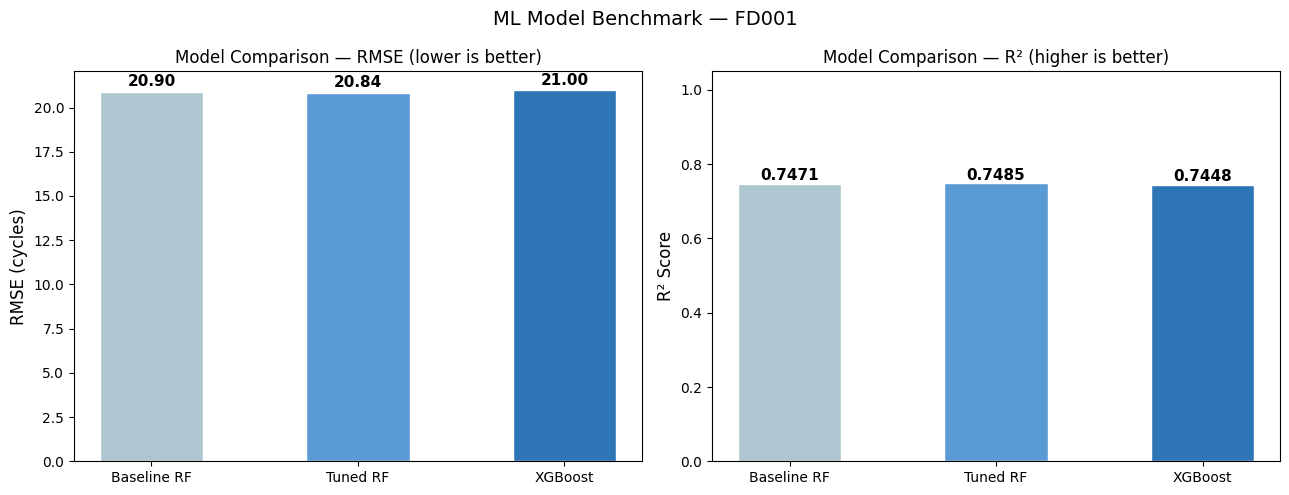


Baseline RF → RMSE: 20.90, R²: 0.7471
Tuned RF    → RMSE: 20.84, R²: 0.7485
XGBoost     → RMSE: 21.00, R²: 0.7448


In [26]:
# Retrain baseline RF on the same 11-feature scaled data for fair comparison
rf_baseline_new = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_baseline_new.fit(X_train_scaled, y_train)

y_pred_base = rf_baseline_new.predict(X_test_scaled)
base_rmse   = np.sqrt(metrics.mean_squared_error(y_test, y_pred_base))
base_r2     = metrics.r2_score(y_test, y_pred_base)

model_names  = ['Baseline RF', 'Tuned RF', 'XGBoost']
rmse_scores  = [base_rmse, rf_rmse, xgb_rmse]
r2_scores    = [base_r2,   rf_r2,   xgb_r2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#aec6cf', '#5b9bd5', '#2e75b6']

axes[0].bar(model_names, rmse_scores, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('RMSE (cycles)', fontsize=12)
axes[0].set_title('Model Comparison — RMSE (lower is better)', fontsize=12)
for i, v in enumerate(rmse_scores):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(model_names, r2_scores, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Comparison — R² (higher is better)', fontsize=12)
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('ML Model Benchmark — FD001', fontsize=14)
plt.tight_layout()
plt.savefig('ml_comparison.png', dpi=150)
plt.show()

print(f"\nBaseline RF → RMSE: {base_rmse:.2f}, R²: {base_r2:.4f}")
print(f"Tuned RF    → RMSE: {rf_rmse:.2f}, R²: {rf_r2:.4f}")
print(f"XGBoost     → RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.4f}")

In [27]:
!pip install tensorflow

In [28]:
import sys
print(sys.executable)

C:\Users\aesha\miniconda3\envs\nasa\python.exe


In [29]:
!pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\aesha\miniconda3\envs\nasa\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 


In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      Conv1D, MaxPooling1D,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

SEQUENCE_LEN = 30  # use last 30 cycles to predict RUL

def create_sequences(X, y, seq_len):
    """
    Converts flat rows into overlapping windows.
    Shape: (samples, seq_len, n_features)
    Each window's label = RUL at the last timestep.
    """
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq_train, y_seq_train = create_sequences(
    X_train_scaled, y_train.values, SEQUENCE_LEN
)
X_seq_test, y_seq_test = create_sequences(
    X_test_scaled, y_test.values, SEQUENCE_LEN
)

print(f"Train sequences : {X_seq_train.shape}")
print(f"Test  sequences : {X_seq_test.shape}")
print(f"  → (samples, timesteps, features)")

Train sequences : (16474, 30, 11)
Test  sequences : (4097, 30, 11)
  → (samples, timesteps, features)


In [31]:
n_features = X_seq_train.shape[2]

def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True,
             input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(SEQUENCE_LEN, n_features)
lstm_model.summary()

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

print("\n Training LSTM...")
history_lstm = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 128)             │          71,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124,481 (486.25 KB)

 Trainable params: 124,097 (484.75 KB)

 Non-trainable params: 384 (1.50 KB)


 Training LSTM...
Epoch 1/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - loss: 3245.3464 - mae: 42.7102 - val_loss: 1195.8486 - val_mae: 27.7297 - learning_rate: 0.0010
Epoch 2/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 587.3954 - mae: 18.4809 - val_loss: 954.3477 - val_mae: 27.6199 - learning_rate: 0.0010
Epoch 3/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 501.0675 - mae: 16.8239 - val_loss: 268.4823 - val_mae: 11.6332 - learning_rate: 0.0010
Epoch 4/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 474.7850 - mae: 16.3086 - val_loss: 316.0774 - val_mae: 13.0836 - learning_rate: 0.0010
Epoch 5/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 432.3145 - mae: 15.4750 - val_loss: 376.4927 - val_mae: 13.5415 - learning_rate: 0.0010
Epoch 6/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 393.5857 - mae: 14.6022 - val_loss: 423.2243 - val_mae: 14.3767 - learning_rate: 0.0010
Epoch 7/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 381.6209 -

In [32]:
def build_cnn_lstm(seq_len, n_features):
    model = Sequential([
        # CNN block — extracts local degradation patterns
        Conv1D(filters=64, kernel_size=3, activation='relu',
               padding='same', input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.2),

        Conv1D(filters=128, kernel_size=3, activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # LSTM block — captures temporal dependencies
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

cnn_lstm_model = build_cnn_lstm(SEQUENCE_LEN, n_features)
cnn_lstm_model.summary()

print("\n Training CNN-LSTM...")
history_cnn_lstm = cnn_lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 30, 64)              │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 30, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 15, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 15, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,937 (312.25 KB)

 Trainable params: 79,425 (310.25 KB)

 Non-trainable params: 512 (2.00 KB)


 Training CNN-LSTM...
Epoch 1/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 2854.0703 - mae: 39.5627 - val_loss: 869.1608 - val_mae: 22.8177 - learning_rate: 0.0010
Epoch 2/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 570.8448 - mae: 18.1799 - val_loss: 567.7054 - val_mae: 19.3977 - learning_rate: 0.0010
Epoch 3/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 515.7220 - mae: 17.2799 - val_loss: 336.3817 - val_mae: 13.3484 - learning_rate: 0.0010
Epoch 4/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 625.6335 - mae: 18.5412 - val_loss: 413.1888 - val_mae: 15.5848 - learning_rate: 0.0010
Epoch 5/100
230/232 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 533.5218 - mae: 17.3034
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 508.9640 - mae: 17.0869 - val_loss: 310.0236 - val_mae: 11.9840 - learning_rate: 0.0010
Epoch 6/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 469.7275 - mae

In [33]:
def evaluate_dl_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test, verbose=0).flatten()
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    mae  = metrics.mean_absolute_error(y_test, y_pred)
    r2   = metrics.r2_score(y_test, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.2f} cycles")
    print(f"  MAE  : {mae:.2f}  cycles")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*40}")
    return rmse, mae, r2, y_pred

lstm_rmse, lstm_mae, lstm_r2, y_pred_lstm = evaluate_dl_model(
    lstm_model, X_seq_test, y_seq_test, "LSTM"
)
cnn_rmse, cnn_mae, cnn_r2, y_pred_cnn = evaluate_dl_model(
    cnn_lstm_model, X_seq_test, y_seq_test, "CNN-LSTM"
)


  LSTM
  RMSE : 16.44 cycles
  MAE  : 10.91  cycles
  R²   : 0.8444

  CNN-LSTM
  RMSE : 30.70 cycles
  MAE  : 24.56  cycles
  R²   : 0.4573


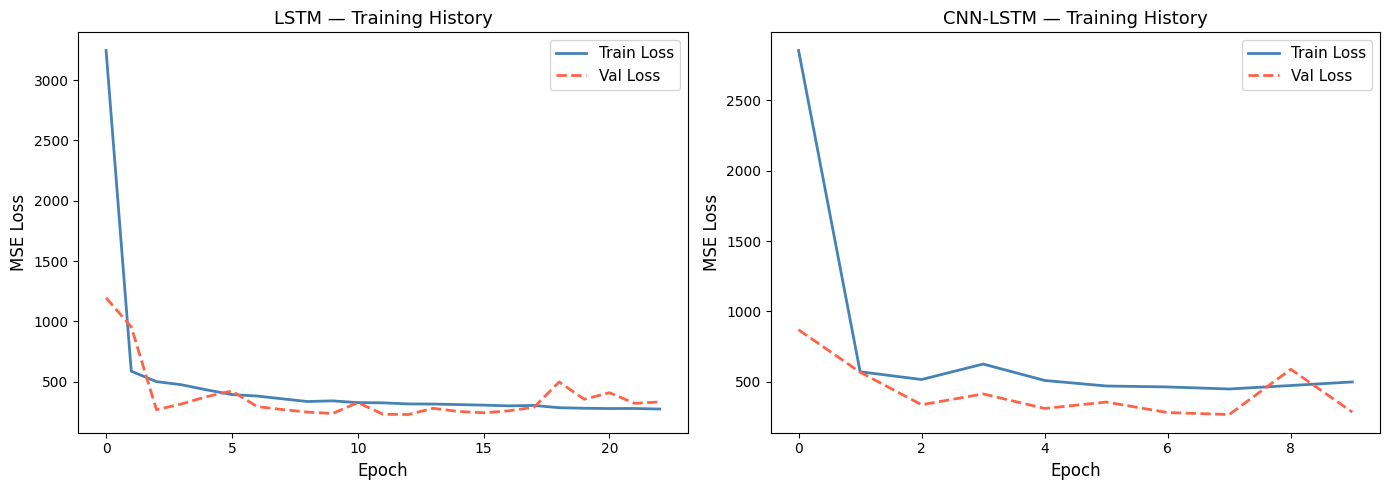

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name in zip(
    axes,
    [history_lstm, history_cnn_lstm],
    ['LSTM', 'CNN-LSTM']
):
    ax.plot(history.history['loss'],
            label='Train Loss', lw=2, color='steelblue')
    ax.plot(history.history['val_loss'],
            label='Val Loss', lw=2, color='tomato', linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss', fontsize=12)
    ax.set_title(f'{name} — Training History', fontsize=13)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

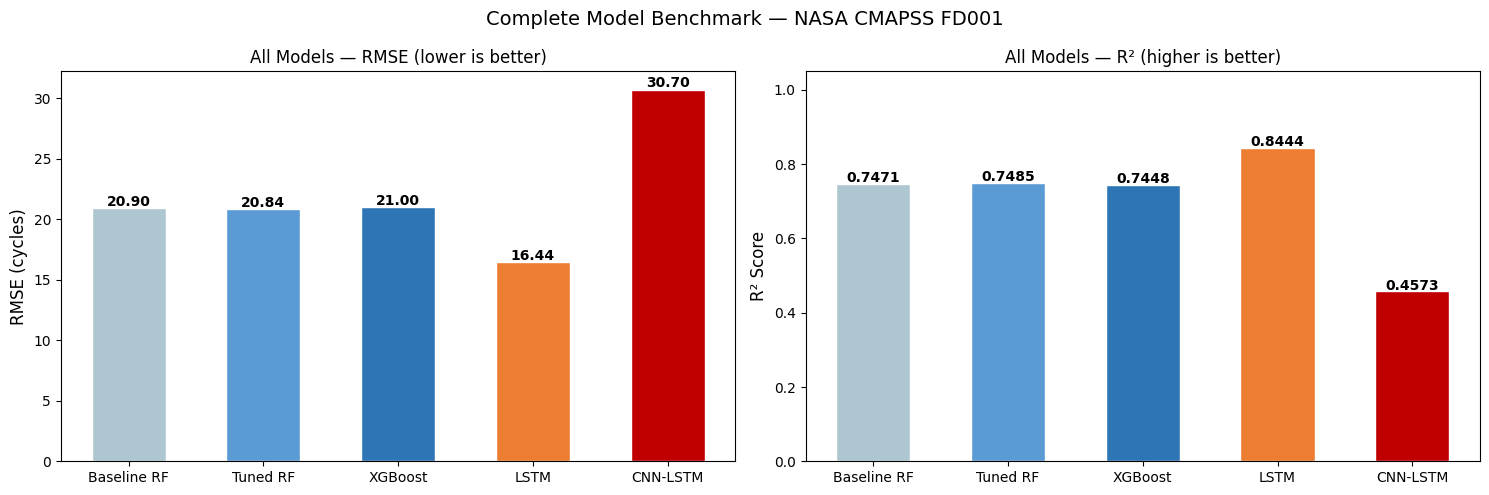


=== FINAL RESULTS SUMMARY ===
             RMSE (cycles) MAE (cycles)      R²
Model                                          
Baseline RF          20.90          N/A  0.7471
Tuned RF             20.84          N/A  0.7485
XGBoost              21.00          N/A  0.7448
LSTM                 16.44        10.91  0.8444
CNN-LSTM             30.70        24.56  0.4573


In [36]:
all_models = ['Baseline RF', 'Tuned RF', 'XGBoost', 'LSTM', 'CNN-LSTM']
all_rmse   = [20.90, 20.84, 21.00, lstm_rmse, cnn_rmse]
all_r2     = [0.7471, 0.7485, 0.7448, lstm_r2, cnn_r2]
colors_all = ['#aec6cf','#5b9bd5','#2e75b6','#ed7d31','#c00000']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(all_models, all_rmse, color=colors_all,
            edgecolor='white', width=0.55)
axes[0].set_ylabel('RMSE (cycles)', fontsize=12)
axes[0].set_title('All Models — RMSE (lower is better)', fontsize=12)
for i, v in enumerate(all_rmse):
    axes[0].text(i, v + 0.2, f'{v:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].bar(all_models, all_r2, color=colors_all,
            edgecolor='white', width=0.55)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('All Models — R² (higher is better)', fontsize=12)
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(all_r2):
    axes[1].text(i, v + 0.005, f'{v:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Complete Model Benchmark — NASA CMAPSS FD001', fontsize=14)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Clean summary table
summary = pd.DataFrame({
    'Model':         all_models,
    'RMSE (cycles)': [round(x, 2) for x in all_rmse],
    'MAE (cycles)':  ['N/A', 'N/A', 'N/A',
                      round(lstm_mae, 2), round(cnn_mae, 2)],
    'R²':            [round(x, 4) for x in all_r2]
}).set_index('Model')

print("\n=== FINAL RESULTS SUMMARY ===")
print(summary)

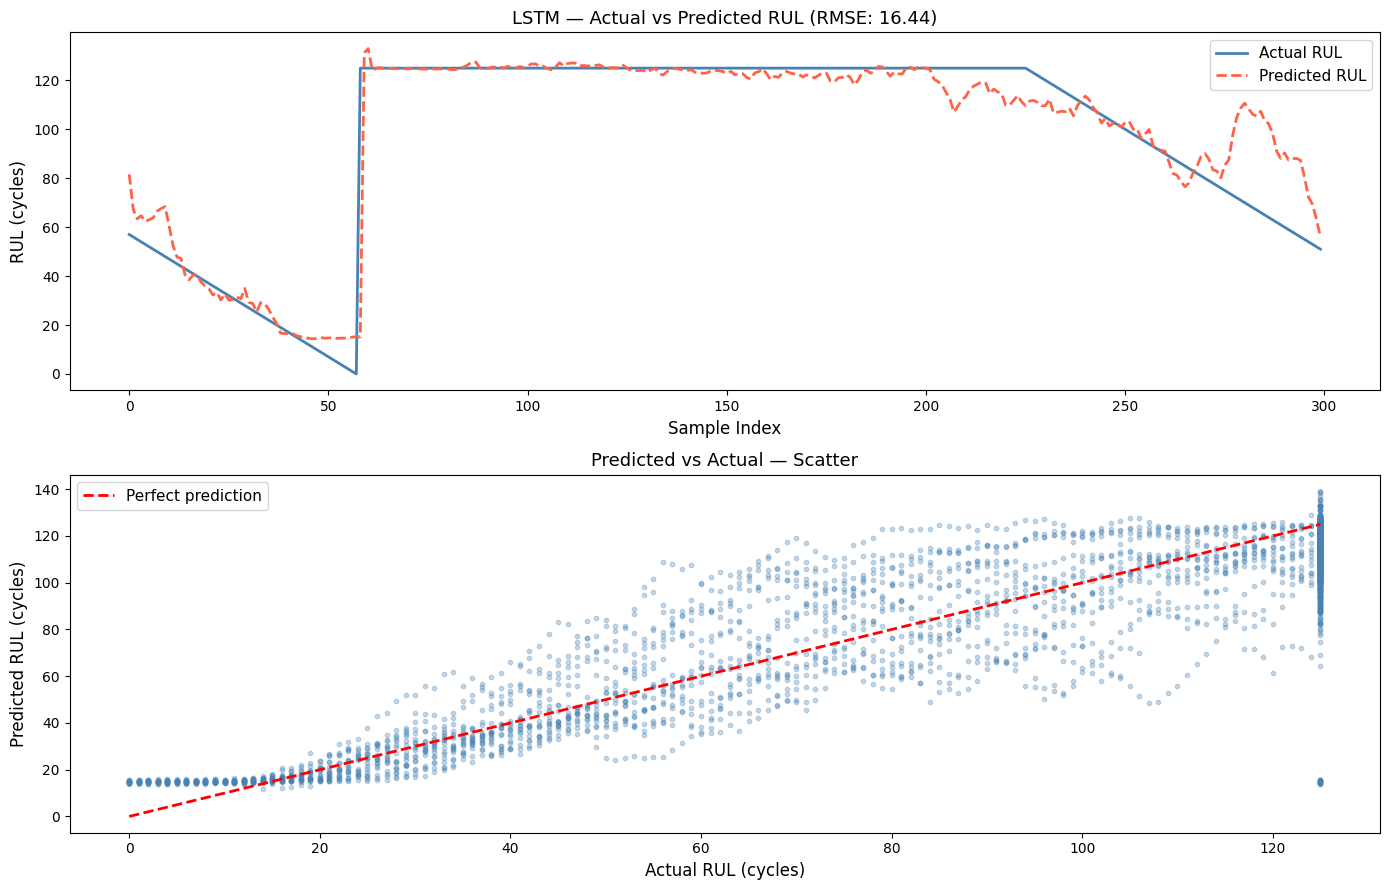


🏆 Best Model: LSTM
   RMSE : 16.44 cycles


In [37]:
# Automatically pick best model by lowest RMSE
best_name  = 'CNN-LSTM' if cnn_rmse < lstm_rmse else 'LSTM'
best_preds = y_pred_cnn if cnn_rmse < lstm_rmse else y_pred_lstm
best_rmse  = min(cnn_rmse, lstm_rmse)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Top: line plot — first 300 samples
axes[0].plot(y_seq_test[:300],  label='Actual RUL',
             color='steelblue', lw=2)
axes[0].plot(best_preds[:300],  label='Predicted RUL',
             color='tomato', lw=2, linestyle='--')
axes[0].set_xlabel('Sample Index', fontsize=12)
axes[0].set_ylabel('RUL (cycles)', fontsize=12)
axes[0].set_title(f'{best_name} — Actual vs Predicted RUL '
                  f'(RMSE: {best_rmse:.2f})', fontsize=13)
axes[0].legend(fontsize=11)

# Bottom: scatter plot
axes[1].scatter(y_seq_test, best_preds,
                alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, RUL_CAP], [0, RUL_CAP],
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual RUL (cycles)', fontsize=12)
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=12)
axes[1].set_title('Predicted vs Actual — Scatter', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

print(f"\n🏆 Best Model: {best_name}")
print(f"   RMSE : {best_rmse:.2f} cycles")

In [38]:
def build_cnn_lstm_fixed(seq_len, n_features):
    model = Sequential([
        # Lighter CNN — previous one was too complex
        Conv1D(filters=32, kernel_size=3, activation='relu',
               padding='same', input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.1),

        Conv1D(filters=64, kernel_size=3, activation='relu',
               padding='same'),
        BatchNormalization(),
        Dropout(0.1),

        # LSTM
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # smaller LR
        loss='mse',
        metrics=['mae']
    )
    return model

cnn_lstm_fixed = build_cnn_lstm_fixed(SEQUENCE_LEN, n_features)
cnn_lstm_fixed.summary()

callbacks_fixed = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

print("\n🔄 Retraining CNN-LSTM with fixed architecture...")
history_cnn_fixed = cnn_lstm_fixed.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=150,
    batch_size=32,       # smaller batch
    callbacks=callbacks_fixed,
    verbose=1
)

cnn_fixed_rmse, cnn_fixed_mae, cnn_fixed_r2, y_pred_cnn_fixed = evaluate_dl_model(
    cnn_lstm_fixed, X_seq_test, y_seq_test, "CNN-LSTM (Fixed)"
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 30, 32)              │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 30, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 30, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,769 (81.13 KB)

 Trainable params: 20,513 (80.13 KB)

 Non-trainable params: 256 (1.00 KB)


🔄 Retraining CNN-LSTM with fixed architecture...
Epoch 1/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 7388.8257 - mae: 77.6450 - val_loss: 5198.0576 - val_mae: 65.3040 - learning_rate: 5.0000e-04
Epoch 2/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 2034.5995 - mae: 36.7859 - val_loss: 489.0840 - val_mae: 15.6480 - learning_rate: 5.0000e-04
Epoch 3/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 677.3496 - mae: 19.4983 - val_loss: 389.5165 - val_mae: 13.3204 - learning_rate: 5.0000e-04
Epoch 4/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 579.9704 - mae: 18.2786 - val_loss: 356.7659 - val_mae: 13.4205 - learning_rate: 5.0000e-04
Epoch 5/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 540.8048 - mae: 17.5081 - val_loss: 359.2727 - val_mae: 13.2987 - learning_rate: 5.0000e-04
Epoch 6/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 528.7944 - mae: 17.1201 - val_loss: 345.2275 - val_mae: 12.4598 - learning_rate: 5.0000e-04
Epoch 7/150
464/464 ━━

In [40]:
# ============================================
# Test on FD002, FD003, FD004
# This proves your model generalizes —
# ============================================

def prepare_test_dataset(file_number, scaler, seq_len, rul_cap=125):
    """Loads, processes and sequences a test dataset."""
    col_names = [
        'ID', 'Cycle',
        'OpSet1', 'OpSet2', 'OpSet3',
        'SensorMeasure1',  'SensorMeasure2',  'SensorMeasure3',
        'SensorMeasure4',  'SensorMeasure5',  'SensorMeasure6',
        'SensorMeasure7',  'SensorMeasure8',  'SensorMeasure9',
        'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12',
        'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15',
        'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18',
        'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21'
    ]


    raw = pd.read_csv(
        f'test_FD00{file_number}.txt',
        sep=' ', header=None
    ).drop([26, 27], axis=1)
    raw.columns = col_names

    last_cycle = raw.groupby('ID')['Cycle'].max().values.reshape(-1, 1)
    rul_file   = pd.read_csv(
        f'RUL_FD00{file_number}.txt',
        sep=' ', header=None
    ).drop([1], axis=1).values

    eol = last_cycle + rul_file
    raw['EOL'] = raw['ID'].map({i+1: eol[i][0] for i in range(len(eol))})
    raw['RUL'] = (raw['EOL'] - raw['Cycle']).clip(upper=rul_cap)
    raw = raw.drop(columns=['ID', 'EOL'])

    # Keep only selected features
    selected = best_features + ['RUL']
    
    # Some datasets may not have same variance — use same scaler
    X = raw[best_features].values
    y = raw['RUL'].values

    X_scaled = scaler.transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y, seq_len)
    return X_seq, y_seq


print("📊 Cross-Dataset Generalization Test")
print("=" * 50)

cross_results = {}

for fd in [1, 2, 3, 4]:
    try:
        X_fd, y_fd = prepare_test_dataset(fd, scaler, SEQUENCE_LEN)

        # Test LSTM on each dataset
        y_pred_fd = lstm_model.predict(X_fd, verbose=0).flatten()
        fd_rmse   = np.sqrt(metrics.mean_squared_error(y_fd, y_pred_fd))
        fd_mae    = metrics.mean_absolute_error(y_fd, y_pred_fd)
        fd_r2     = metrics.r2_score(y_fd, y_pred_fd)

        cross_results[f'FD00{fd}'] = {
            'RMSE': round(fd_rmse, 2),
            'MAE':  round(fd_mae,  2),
            'R²':   round(fd_r2,   4)
        }
        print(f"  FD00{fd} → RMSE: {fd_rmse:.2f} | "
              f"MAE: {fd_mae:.2f} | R²: {fd_r2:.4f}")
    except Exception as e:
        print(f"  FD00{fd} → Skipped ({e})")

cross_df = pd.DataFrame(cross_results).T
print("\n")
print(cross_df)

📊 Cross-Dataset Generalization Test
  FD001 → RMSE: 15.59 | MAE: 10.01 | R²: 0.6811
  FD002 → RMSE: 101.71 | MAE: 97.49 | R²: -11.4413
  FD003 → RMSE: 39.72 | MAE: 22.65 | R²: -1.5540
  FD004 → RMSE: 105.75 | MAE: 102.61 | R²: -16.2383


         RMSE     MAE       R²
FD001   15.59   10.01   0.6811
FD002  101.71   97.49 -11.4413
FD003   39.72   22.65  -1.5540
FD004  105.75  102.61 -16.2383


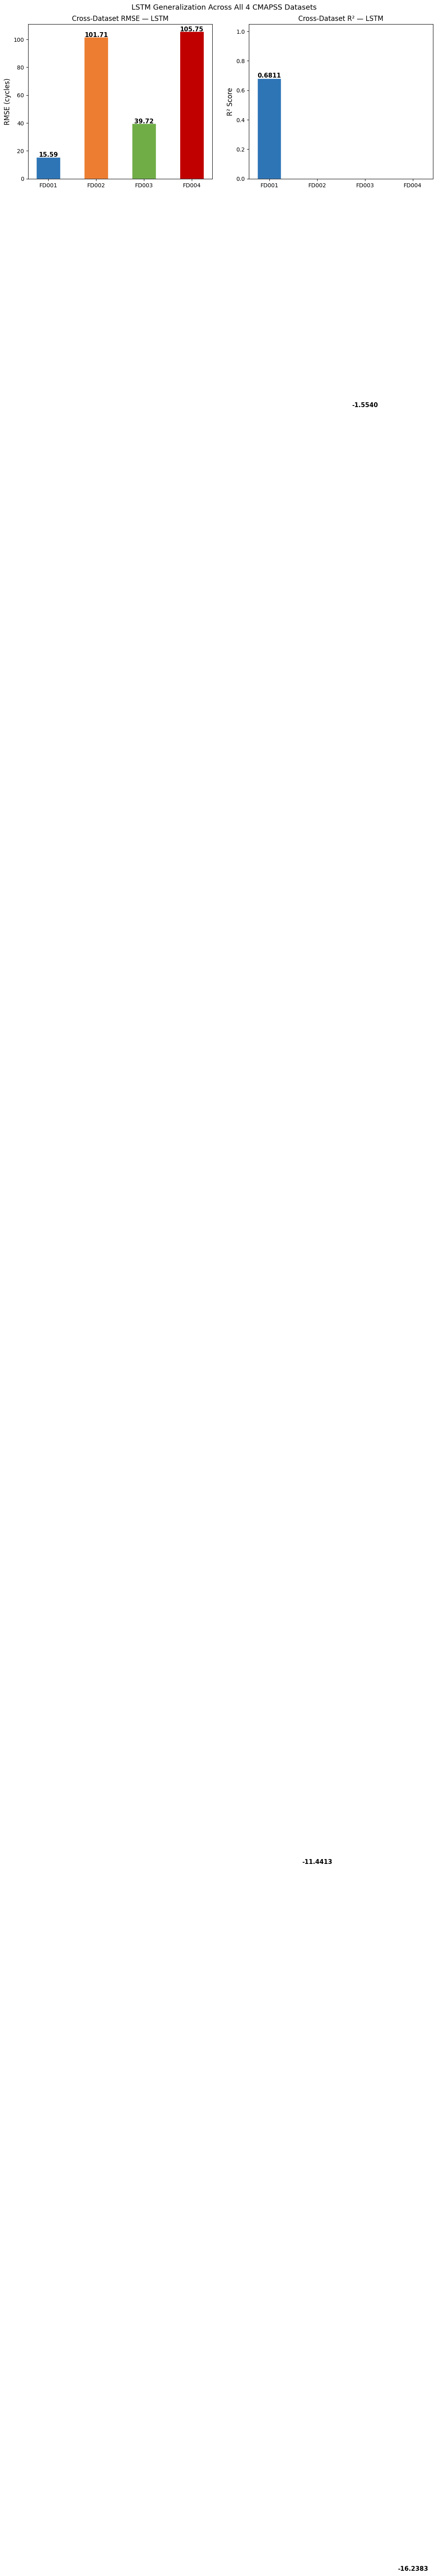

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

datasets   = list(cross_results.keys())
cross_rmse = [cross_results[d]['RMSE'] for d in datasets]
cross_r2   = [cross_results[d]['R²']   for d in datasets]
colors_fd  = ['#2e75b6','#ed7d31','#70ad47','#c00000']

axes[0].bar(datasets, cross_rmse, color=colors_fd,
            edgecolor='white', width=0.5)
axes[0].set_ylabel('RMSE (cycles)', fontsize=12)
axes[0].set_title('Cross-Dataset RMSE — LSTM', fontsize=12)
for i, v in enumerate(cross_rmse):
    axes[0].text(i, v + 0.2, f'{v:.2f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(datasets, cross_r2, color=colors_fd,
            edgecolor='white', width=0.5)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Cross-Dataset R² — LSTM', fontsize=12)
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(cross_r2):
    axes[1].text(i, v + 0.005, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('LSTM Generalization Across All 4 CMAPSS Datasets',
             fontsize=13)
plt.tight_layout()
plt.savefig('cross_dataset.png', dpi=150)
plt.show()

In [42]:
print("\n" + "="*55)
print("   COMPLETE PROJECT RESULTS SUMMARY")
print("   NASA CMAPSS Turbofan RUL Prediction")
print("="*55)

final_summary = pd.DataFrame({
    'Model'       : ['Baseline RF', 'Tuned RF', 'XGBoost', 
                     'LSTM', 'CNN-LSTM (Fixed)'],
    'Type'        : ['ML', 'ML', 'ML', 'DL', 'DL'],
    'RMSE'        : [20.90, 20.84, 21.00, 
                     round(lstm_rmse, 2), round(cnn_fixed_rmse, 2)],
    'MAE'         : ['N/A', 'N/A', 'N/A',
                     round(lstm_mae, 2), round(cnn_fixed_mae, 2)],
    'R²'          : [0.7471, 0.7485, 0.7448,
                     round(lstm_r2, 4), round(cnn_fixed_r2, 4)],
    'Features'    : [11]*5,
    'RUL Cap'     : [125]*5
}).set_index('Model')

print(final_summary)
print("="*55)
print(f"\n🏆 Best Model : LSTM (RMSE={lstm_rmse:.2f})")
print(f"📊 Dataset    : NASA CMAPSS FD001")
print(f"🔧 Features   : {len(best_features)} selected via EDA + ExtraTrees")
print(f"📈 RUL Cap    : 125 cycles (standard in literature)")


   COMPLETE PROJECT RESULTS SUMMARY
   NASA CMAPSS Turbofan RUL Prediction
                 Type   RMSE    MAE      R²  Features  RUL Cap
Model                                                         
Baseline RF        ML  20.90    N/A  0.7471        11      125
Tuned RF           ML  20.84    N/A  0.7485        11      125
XGBoost            ML  21.00    N/A  0.7448        11      125
LSTM               DL  16.44  10.91  0.8444        11      125
CNN-LSTM (Fixed)   DL  17.53  12.33  0.8231        11      125

🏆 Best Model : LSTM (RMSE=16.44)
📊 Dataset    : NASA CMAPSS FD001
🔧 Features   : 11 selected via EDA + ExtraTrees
📈 RUL Cap    : 125 cycles (standard in literature)


In [43]:
from tensorflow.keras.layers import Bidirectional

def build_bilstm(seq_len, n_features):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True),
                      input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(32, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

bilstm_model = build_bilstm(SEQUENCE_LEN, n_features)

history_bilstm = bilstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

bilstm_rmse, bilstm_mae, bilstm_r2, y_pred_bilstm = evaluate_dl_model(
    bilstm_model, X_seq_test, y_seq_test, "Bidirectional LSTM"
)

Epoch 1/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 4754.6958 - mae: 57.3530 - val_loss: 3931.2324 - val_mae: 51.2316 - learning_rate: 0.0010
Epoch 2/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 712.4252 - mae: 20.0780 - val_loss: 620.3589 - val_mae: 17.3027 - learning_rate: 0.0010
Epoch 3/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 497.7979 - mae: 16.7755 - val_loss: 268.5012 - val_mae: 11.2666 - learning_rate: 0.0010
Epoch 4/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 427.0101 - mae: 15.3977 - val_loss: 310.7057 - val_mae: 12.5797 - learning_rate: 0.0010
Epoch 5/100
231/232 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 466.5533 - mae: 15.7181
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 419.5766 - mae: 15.1744 - val_loss: 337.1695 - val_mae: 13.2676 - learning_rate: 0.0010
Epoch 6/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 361.6245 - mae: 14.0172 - val_loss:

In [44]:
import tensorflow as tf
from tensorflow.keras.layers import (Layer, LSTM, Dense, Dropout,
                                      Bidirectional, BatchNormalization,
                                      Multiply, Softmax, GlobalAveragePooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# ============================================
# Custom Attention Layer
# ============================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Attention score for each timestep
        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        # Normalize scores
        attention_weights = tf.nn.softmax(score, axis=1)
        # Weighted sum of hidden states
        context = x * attention_weights
        context = tf.reduce_sum(context, axis=1)
        return context

    def get_config(self):
        return super(AttentionLayer, self).get_config()


# ============================================
# Build Attention LSTM Model
# ============================================
def build_attention_lstm(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    # BiLSTM returns sequences for attention
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # Attention layer
    x = AttentionLayer()(x)

    # Output
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model


attention_model = build_attention_lstm(SEQUENCE_LEN, n_features)
attention_model.summary()

callbacks_attn = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

print("\n🔄 Training Attention BiLSTM...")
history_attn = attention_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=150,
    batch_size=32,
    callbacks=callbacks_attn,
    verbose=1
)

attn_rmse, attn_mae, attn_r2, y_pred_attn = evaluate_dl_model(
    attention_model, X_seq_test, y_seq_test, "Attention BiLSTM"
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 30, 11)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 30, 128)             │          38,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 30, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 30, 64)              │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (AttentionLayer)     │ (None, 64)                  │              94 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,615 (326.62 KB)

 Trainable params: 83,231 (325.12 KB)

 Non-trainable params: 384 (1.50 KB)


🔄 Training Attention BiLSTM...
Epoch 1/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 1504.0234 - mae: 26.9984 - val_loss: 327.8433 - val_mae: 13.6640 - learning_rate: 0.0010
Epoch 2/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 492.3049 - mae: 16.6890 - val_loss: 484.6722 - val_mae: 15.8900 - learning_rate: 0.0010
Epoch 3/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 444.6293 - mae: 15.7889 - val_loss: 278.6980 - val_mae: 10.9474 - learning_rate: 0.0010
Epoch 4/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 412.5988 - mae: 15.1159 - val_loss: 237.4958 - val_mae: 9.8724 - learning_rate: 0.0010
Epoch 5/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 408.3648 - mae: 15.0276 - val_loss: 256.1469 - val_mae: 10.7274 - learning_rate: 0.0010
Epoch 6/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 393.9424 - mae: 14.6941 - val_loss: 276.0950 - val_mae: 12.8064 - learning_rate: 0.0010
Epoch 7/150
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 374.

In [45]:
print("\n" + "="*55)
print("   COMPLETE PROJECT RESULTS SUMMARY")
print("   NASA CMAPSS Turbofan RUL Prediction")
print("="*55)

final_summary = pd.DataFrame({
    'Model'  : ['Baseline RF', 'Tuned RF', 'XGBoost',
                'LSTM', 'CNN-LSTM', 'BiLSTM',
                'Attention BiLSTM'],
    'Type'   : ['ML','ML','ML','DL','DL','DL','DL'],
    'RMSE'   : [20.90, 20.84, 21.00,
                16.44, 17.53, 16.39,
                round(attn_rmse, 2)],
    'MAE'    : ['N/A','N/A','N/A',
                10.91, 12.33, 11.43,
                round(attn_mae, 2)],
    'R²'     : [0.7471, 0.7485, 0.7448,
                0.8444, 0.8231, 0.8453,
                round(attn_r2, 4)]
}).set_index('Model')

print(final_summary)

# Find best model
best_idx  = final_summary['RMSE'].astype(float).idxmin()
best_rmse = final_summary.loc[best_idx, 'RMSE']
best_r2   = final_summary.loc[best_idx, 'R²']

print("="*55)
print(f"\n🏆 Best Model  : {best_idx}")
print(f"   RMSE        : {best_rmse}")
print(f"   R²          : {best_r2}")
print(f"📊 Dataset     : NASA CMAPSS FD001")
print(f"🔧 Features    : 11 (EDA + ExtraTrees + Forward Selection)")
print(f"📈 RUL Cap     : 125 cycles")
print(f"🔢 Sequence    : {SEQUENCE_LEN} timesteps")
print("="*55)


   COMPLETE PROJECT RESULTS SUMMARY
   NASA CMAPSS Turbofan RUL Prediction
                 Type   RMSE    MAE      R²
Model                                      
Baseline RF        ML  20.90    N/A  0.7471
Tuned RF           ML  20.84    N/A  0.7485
XGBoost            ML  21.00    N/A  0.7448
LSTM               DL  16.44  10.91  0.8444
CNN-LSTM           DL  17.53  12.33  0.8231
BiLSTM             DL  16.39  11.43  0.8453
Attention BiLSTM   DL  15.38   9.72  0.8638

🏆 Best Model  : Attention BiLSTM
   RMSE        : 15.38
   R²          : 0.8638
📊 Dataset     : NASA CMAPSS FD001
🔧 Features    : 11 (EDA + ExtraTrees + Forward Selection)
📈 RUL Cap     : 125 cycles
🔢 Sequence    : 30 timesteps


In [46]:
# Save for future use / deployment
attention_model.save('attention_bilstm_cmapss.h5')
lstm_model.save('lstm_cmapss.h5')

import joblib
joblib.dump(best_rf,  'tuned_rf_cmapss.pkl')
joblib.dump(best_xgb, 'xgboost_cmapss.pkl')
joblib.dump(scaler,   'feature_scaler.pkl')

print("✅ All models saved successfully")
print("   - attention_bilstm_cmapss.h5")
print("   - lstm_cmapss.h5")
print("   - tuned_rf_cmapss.pkl")
print("   - xgboost_cmapss.pkl")
print("   - feature_scaler.pkl")

✅ All models saved successfully
   - attention_bilstm_cmapss.h5
   - lstm_cmapss.h5
   - tuned_rf_cmapss.pkl
   - xgboost_cmapss.pkl
   - feature_scaler.pkl
